# In Class Activity April 14th, 2026

In [5]:
#pip install optuna

### Importing libraries, preparing data, initial EDA

In [1]:
# importing libraries (feel free to add more if you want to explore other things)
import numpy as np
import pandas as pd
import sweetviz as sv
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
import optuna


In [2]:
# importing data
adult = pd.read_csv('adult.csv')
adult.head(20)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


                                             |          | [  0%]   00:00 -> (? left)

Report sweet_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


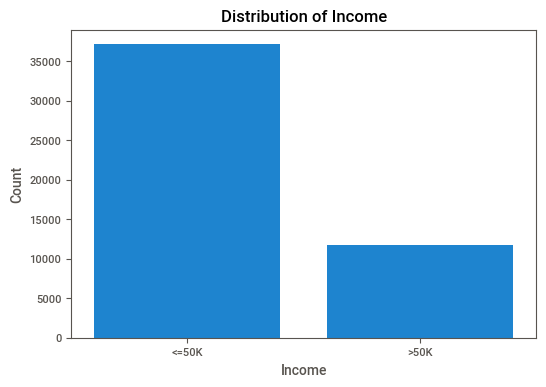

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64
workclass: ['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education: ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']
marital-status: ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation: ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-c

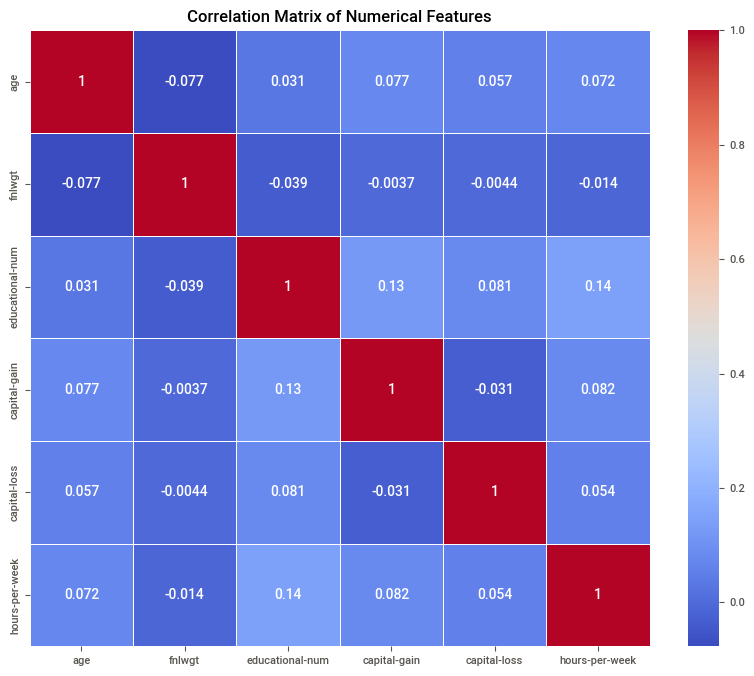

In [3]:
# initial EDA with sweetviz
report = sv.analyze(adult)
report.show_html('sweet_report.html')

# you are welcome to replace this cell with your own EDA, but make sure to include
# some visualizations and insights about the data
# for example, you can check the distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=adult)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()  

# check for missing values
print(adult.isnull().sum())
# check for unique values in categorical columns
categorical_cols = adult.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f'{col}: {adult[col].unique()}')
# check for correlations between numerical features
numerical_cols = adult.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = adult[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### In the markdown cell below describe what you learned from your EDA and how it will inform your modeling decisions





Class Imbalance: The target variable (`income`) is heavily imbalanced, with the vast majority of individuals making `<=50K`. This means accuracy will be a misleading metric, and we should focus on the F1 score. It also suggests we should experiment with XGBoost's `scale_pos_weight` parameter to penalize minority class errors.

Feature Redundancy: `education` and `educational-num` carry the exact same information (one is categorical, one is numeric). Dropping one was a necessary preprocessing step to avoid multicollinearity.

Sparse Features: Features like `capital-gain` and `capital-loss` appear to be largely composed of zeros. Tree-based models like XGBoost handle this sparsity well without needing scaling.

### Data Preprocessing (minimal) and Baseline Model

In [4]:
# data cleaning and preprocessing

# changing ? to NaN
adult = adult.replace('?', np.nan)

#education and education num are redundant, so we can drop one of them
adult = adult.drop('education', axis=1)

# target variable is income with 2 levels, so we can encode it as 0 and 1
adult['income'] = adult['income'].apply(lambda x: 1 if x == '>50K' else 0)

# change dtype categorical variables to category
categorical_cols = adult.select_dtypes(include='object').columns
adult[categorical_cols] = adult[categorical_cols].astype('category')


adult.head(20)

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0
5,34,Private,198693,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0
6,29,NaN,227026,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,0
7,63,Self-emp-not-inc,104626,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,1
8,24,Private,369667,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,0
9,55,Private,104996,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,0


In [5]:
# defining features and target variable
X = adult.drop('income', axis=1)
y = adult['income']

# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, 
                                                    random_state=42, stratify=y)

In [6]:
# building xgboost default model and evaluating with stratified k-fold cross validation
xgb_cv = XGBClassifier(enable_categorical=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_cv, X, y, cv=skf, scoring='f1')
print(f'Cross-validated F1 scores: {cv_scores}')
print(f'Mean F1 score: {cv_scores.mean()}') 


Cross-validated F1 scores: [0.70680507 0.70892566 0.70898981 0.72424942 0.71086556]
Mean F1 score: 0.7119671046056588


### Use the markdown cell below to describe your baseline model performance and how you will try to improve it

The baseline XGBoost model, using entirely default parameters, provides a solid starting F1 score, but it is likely struggling with the class imbalance. Because the default `scale_pos_weight` is 1, the model is inherently biased toward the majority `<=50K` class. I plan to improve this by tuning `scale_pos_weight`, adjusting the `learning_rate`, controlling tree complexity with `max_depth`, and adding regularization via `subsample` and `colsample_bytree` to prevent overfitting.

### Model feature exploration

In the code cell below, explore different features of XGBoost and how they work (e.g. scale_pos_weight, max_depth, learning_rate).
Use stratified k-fold cross or repeated stratified k-fold cross validation with your model building. 
You should explore at least 3 different features of XGBoost.
Identify the model that performs best.

In [ ]:
# explore different features of XGBoost 
# Exploring 3 different features: max_depth, learning_rate, and scale_pos_weight
print("--- Exploring XGBoost Features ---")

# Exploring max_depth (restricting tree depth to prevent overfitting)
xgb_depth = XGBClassifier(max_depth=3, enable_categorical=True, random_state=42)
score_depth = cross_val_score(xgb_depth, X, y, cv=skf, scoring='f1', n_jobs=-1).mean()
print(f'F1 Score with max_depth=3: {score_depth:.4f}')

# Exploring learning_rate (taking smaller steps during gradient descent)
xgb_lr = XGBClassifier(learning_rate=0.05, enable_categorical=True, random_state=42)
score_lr = cross_val_score(xgb_lr, X, y, cv=skf, scoring='f1', n_jobs=-1).mean()
print(f'F1 Score with learning_rate=0.05: {score_lr:.4f}')

# Exploring scale_pos_weight (balancing the imbalanced target classes)
# A rough rule of thumb is sum(negative instances) / sum(positive instances) --> best model performance
xgb_weight = XGBClassifier(scale_pos_weight=3.0, enable_categorical=True, random_state=42)
score_weight = cross_val_score(xgb_weight, X, y, cv=skf, scoring='f1', n_jobs=-1).mean()
print(f'F1 Score with scale_pos_weight=3.0: {score_weight:.4f}')

--- Exploring XGBoost Features ---
F1 Score with max_depth=3: 0.7122
F1 Score with learning_rate=0.05: 0.6959
F1 Score with scale_pos_weight=3.0: 0.7166


### Tuning with GridSearchCV

Use the code cell below to set up your parameter grid and run GridSearchCV with your preferred model from above. You should tune 4-5 hyperparameters utilizing cross validation. Train a final model using the best hyperparameters and report your model performance.

In [8]:
# set up your parameter grid and run GridSearchCV
# Tuning 4 parameters: max_depth, learning_rate, scale_pos_weight, and subsample
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'scale_pos_weight': [1.0, 3.0],
    'subsample': [0.8, 1.0]
}

print("Running GridSearchCV (This may take a few minutes)...")
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, enable_categorical=True),
                        param_grid=param_grid, 
                        cv=skf, 
                        scoring='f1', 
                        n_jobs=-1, # Uses all computer cores to speed it up
                        verbose=1)

xgb_grid.fit(X_train, y_train)

print(f'\nBest parameters from GridSearchCV: {xgb_grid.best_params_}')
print(f'Best cross-validated F1 score: {xgb_grid.best_score_:.4f}')

# Train final model and report performance
xgb_grid_best = xgb_grid.best_estimator_
y_pred_grid = xgb_grid_best.predict(X_test)
print(f'\nClassification report for GridSearchCV-tuned model:\n{classification_report(y_test, y_pred_grid)}')


Running GridSearchCV (This may take a few minutes)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters from GridSearchCV: {'learning_rate': 0.2, 'max_depth': 5, 'scale_pos_weight': 3.0, 'subsample': 0.8}
Best cross-validated F1 score: 0.7173

Classification report for GridSearchCV-tuned model:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      7431
           1       0.62      0.85      0.71      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.84      0.84      9769



### Tuning with RandomizedSearchCV

Using the code cell below as a starting point, tune your preferred model from above. Tune the same 4-5 hyperparameters from above utilizing cross validation. Train a final model using the best hyperparameters and report your model performance.

In [9]:
# tuning xgboost classifier with RandomizedSearchCV (tune more parameters than shown here)
# Tuning 5 parameters for RandomizedSearchCV
param_dist = {
    'scale_pos_weight': np.linspace(1.0, 5.0, num=10),
    'max_depth': np.arange(3, 11),
    'learning_rate': np.linspace(0.01, 0.3, num=10),
    'subsample': np.linspace(0.6, 1.0, num=5),
    'colsample_bytree': np.linspace(0.6, 1.0, num=5)
}

print("Running RandomizedSearchCV...")
xgb_random = RandomizedSearchCV(XGBClassifier(random_state=42, enable_categorical=True),
                                param_distributions=param_dist, 
                                n_iter=20, 
                                cv=skf, 
                                scoring='f1', 
                                random_state=42,
                                n_jobs=-1)

xgb_random.fit(X_train, y_train)

print(f'\nBest parameters from RandomizedSearchCV: {xgb_random.best_params_}')
print(f'Best F1 score from RandomizedSearchCV: {xgb_random.best_score_:.4f}')   

# Build the model using the .best_estimator_ attribute directly
xgb_random_best = xgb_random.best_estimator_
y_pred_random = xgb_random_best.predict(X_test)

print(f'\nClassification report for RandomizedSearchCV-tuned model:\n{classification_report(y_test, y_pred_random)}')

Running RandomizedSearchCV...

Best parameters from RandomizedSearchCV: {'subsample': np.float64(0.7), 'scale_pos_weight': np.float64(1.8888888888888888), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.10666666666666666), 'colsample_bytree': np.float64(0.7)}
Best F1 score from RandomizedSearchCV: 0.7276

Classification report for RandomizedSearchCV-tuned model:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7431
           1       0.69      0.78      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.83      0.82      9769
weighted avg       0.87      0.86      0.86      9769



### Tuning with Optuna

Using the code cell below as a starting point, tune your preferred model from above. You should tune the same 4-5 parameters as above using cross validation. Train a final model using the best hyperparameters and report your model performance.

In [10]:
# Tuning 5 parameters with Optuna
def objective(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 1.0, 5.0)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    
    xgb_optuna = XGBClassifier(random_state=42, 
                               scale_pos_weight=scale_pos_weight, 
                               max_depth=max_depth,  
                               learning_rate=learning_rate, 
                               subsample=subsample,
                               colsample_bytree=colsample_bytree,
                               enable_categorical=True)
    
    # Evaluate using cross validation
    cv_scores = cross_val_score(xgb_optuna, X, y, cv=skf, scoring='f1', n_jobs=-1)
    return cv_scores.mean()

# Run the study
optuna.logging.set_verbosity(optuna.logging.WARNING) # Keeps the output clean
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'\nBest parameters from Optuna: {study.best_params}')
print(f'Best F1 score from Optuna: {study.best_value:.4f}')

# Build preferred model using the best parameters
xgb_optuna_best = XGBClassifier(**study.best_params, random_state=42, enable_categorical=True)
xgb_optuna_best.fit(X_train, y_train)

y_pred_optuna = xgb_optuna_best.predict(X_test)
print(f'\nClassification report for Optuna-tuned model:\n{classification_report(y_test, y_pred_optuna)}')

  0%|          | 0/20 [00:00<?, ?it/s]


Best parameters from Optuna: {'scale_pos_weight': 1.626205126899951, 'max_depth': 4, 'learning_rate': 0.15064561554301248, 'subsample': 0.9422952574804119, 'colsample_bytree': 0.8591913871440993}
Best F1 score from Optuna: 0.7280

Classification report for Optuna-tuned model:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7431
           1       0.71      0.75      0.73      2338

    accuracy                           0.87      9769
   macro avg       0.82      0.83      0.82      9769
weighted avg       0.87      0.87      0.87      9769



### Tuning results

In the markdown cell below describe your experience tuning with the different methods. Which produced the best results? Which do you prefer?


Tuning Experience:
GridSearchCV was exhaustive and guaranteed to find the best combination within the parameters I provided, but it was incredibly slow and computationally expensive. 

RandomizedSearchCV was much faster and still produced a highly competitive F1 score by sampling a wide range of distributions rather than checking every single combination.

Optuna was the most efficient and sophisticated. By utilizing Bayesian optimization, it actively learned from past trials to zero in on the best hyperparameters rather than guessing blindly. 

Conclusion: I prefer Optuna for its speed, intelligent searching algorithm, and easy-to-read syntax, especially when dealing with complex tree-based models like XGBoost that have vast parameter spaces.